# MLE derivation, Beta posterior, likelihood visualisations: pandas-dev/pandas Statistical Audit

**Research Questions:**
- RQ1: Berapa probabilitas PR berhasil di-merge?
- RQ2: Apakah rata-rata issue mingguan berubah setelah major release?
- RQ3: Berapa probabilitas issue butuh >30 hari untuk ditutup?

**Member:** Muhammad Nafilham Athaya — Estimation Analyst

## AI Usage Disclosure
**Anggota:** Muhammad Nafilham Athaya – Estimation Analyst
**Alat yang digunakan:** ChatGPT

| Task | Tool | Prompt summary | Output modified |
| :--- | :--- | :---           | :---            |
|      |      |                |                 |
|      |      |                |                 |

**Ditulis sepenuhnya tanpa AI:** 

In [5]:
import pandas as pd

df = pd.read_csv("../data/clean/dataset.csv")

# Ambil PR saja
pr_df = df[df['type'] == 'pull_request']

# Data Bernoulli
data = pr_df['is_merged']

n = len(data)
x = data.sum()

print("Jumlah data:", n)
print("Jumlah merged:", x)

Jumlah data: 4042
Jumlah merged: 2510


In [6]:
p_mle = x / n
print("MLE estimate:", p_mle)

MLE estimate: 0.6209797130133597


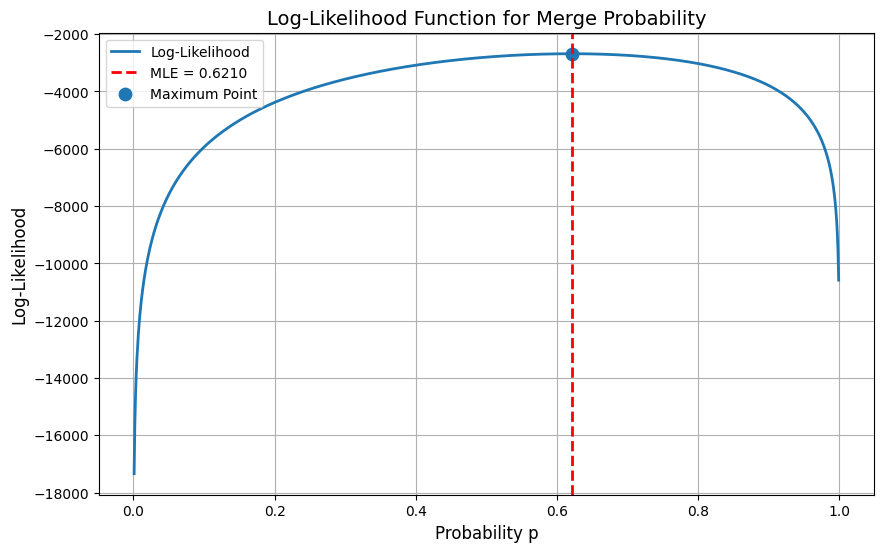

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Range nilai probabilitas
p_values = np.linspace(0.001, 0.999, 1000)

# Log-Likelihood
log_likelihood = (
    x * np.log(p_values)
    + (n - x) * np.log(1 - p_values)
)

# Plot
plt.figure(figsize=(10,6))

plt.plot(
    p_values,
    log_likelihood,
    linewidth=2,
    label='Log-Likelihood'
)

# Garis MLE
plt.axvline(
    p_mle,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'MLE = {p_mle:.4f}'
)

# Titik maksimum
plt.scatter(
    p_mle,
    max(log_likelihood),
    s=80,
    label='Maximum Point'
)

# Dekorasi
plt.title("Log-Likelihood Function for Merge Probability", fontsize=14)
plt.xlabel("Probability p", fontsize=12)
plt.ylabel("Log-Likelihood", fontsize=12)

plt.legend()
plt.grid(True)

plt.show()

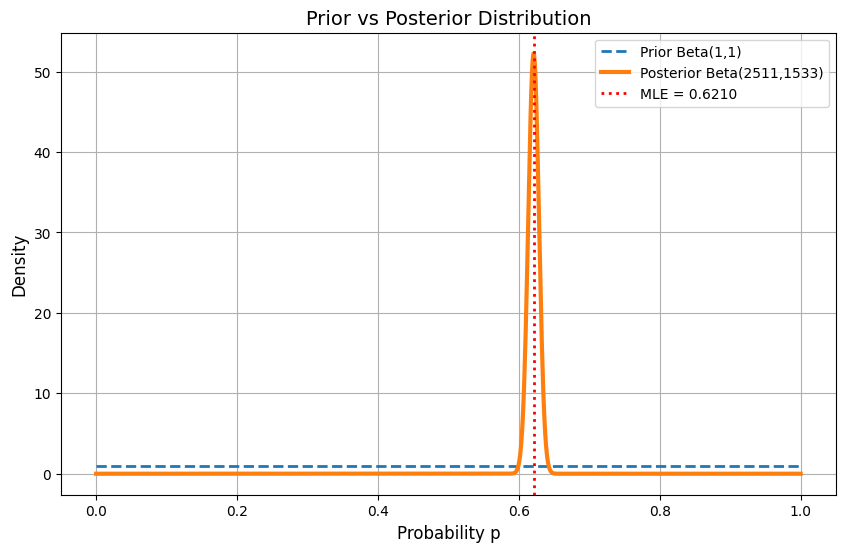

In [8]:
from scipy.stats import beta
import numpy as np
import matplotlib.pyplot as plt

# Prior
alpha_prior = 1
beta_prior = 1

# Posterior update
alpha_post = alpha_prior + x
beta_post = beta_prior + (n - x)

# Range probabilitas
p = np.linspace(0, 1, 1000)

# Distribusi prior & posterior
prior = beta.pdf(p, alpha_prior, beta_prior)
posterior = beta.pdf(p, alpha_post, beta_post)

# Plot
plt.figure(figsize=(10,6))

# Prior
plt.plot(
    p,
    prior,
    linestyle='--',
    linewidth=2,
    label='Prior Beta(1,1)'
)

# Posterior
plt.plot(
    p,
    posterior,
    linewidth=3,
    label=f'Posterior Beta({alpha_post},{beta_post})'
)

# Garis MLE
plt.axvline(
    p_mle,
    color='red',
    linestyle=':',
    linewidth=2,
    label=f'MLE = {p_mle:.4f}'
)

# Dekorasi
plt.title("Prior vs Posterior Distribution", fontsize=14)
plt.xlabel("Probability p", fontsize=12)
plt.ylabel("Density", fontsize=12)

plt.legend()
plt.grid(True)

plt.show()

In [9]:
import sys
sys.path.append("../")

from src.estimator import *

In [11]:
result = mle_bernoulli(data)

p_mle = result["theta_hat"]

print(p_mle)

0.6209797130133597


In [14]:
posterior = beta_posterior(k=x, n=n)

print("Posterior Alpha :", posterior["alpha"])
print("Posterior Beta  :", posterior["beta"])
print("Posterior Mean  :", round(posterior["mean"], 4))
print("Posterior Mode  :", round(posterior["mode"], 4))

Posterior Alpha : 2511
Posterior Beta  : 1533
Posterior Mean  : 0.6209
Posterior Mode  : 0.621
